# Import and optimization

In [11]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import missingno
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.express as px
import phik
from pygeodesy import GeoidKarney, LatLon_

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
class CFG:
    TARGET = ['GGFM_f']
    N_FOLDS = 5
    RANDOM_STATE = 3

    COLORADO_PATH = './Data/Synt/Colorado_600_merge.csv'
    NSO_PATH = './Data/Synt/NSO_600_merge.csv'
    COLORADO_PATH = NSO_PATH

In [14]:
class DataLoader:
    def __init__(self, colorado: pd.DataFrame, nso: pd.DataFrame):
        self.colorado = colorado
        self.nso = nso
        self.log_features = []  # Список признаков для трансформации
        self.X = None
        self.y = None
    

    @staticmethod
    def reduce_mem_usage(dataframe):
        """ 
        Уменьшает использование памяти dataframe путем преобразования типов данных
        с автоматическим пропуском временных столбцов
        """
        start_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Изначальное использование памяти: {start_mem:.2f} MB")
        
        for col in dataframe.columns:
            col_type = dataframe[col].dtype
            
            # Пропускаем временные столбцы и категориальные данные
            if str(col_type).startswith('datetime') or str(col_type) == 'category':
                continue
                
            if col_type != object:
                c_min = dataframe[col].min()
                c_max = dataframe[col].max()
                
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        dataframe[col] = dataframe[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        dataframe[col] = dataframe[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        dataframe[col] = dataframe[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        dataframe[col] = dataframe[col].astype(np.int64)
                else:
                    if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        dataframe[col] = dataframe[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        dataframe[col] = dataframe[col].astype(np.float32)
                    else:
                        dataframe[col] = dataframe[col].astype(np.float64)
            else:
                # Оптимизация строковых столбцов
                dataframe[col] = dataframe[col].astype('category')
        
        end_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Итоговое использование памяти: {end_mem:.2f} MB")
        print(f"Экономия {(start_mem - end_mem) / start_mem * 100:.1f}%")
        
        return dataframe


    def load(self, option='colorado'):
        print(f'Loading data')
        print(f'Choosed option:{option}')

        if option == 'compare':
            self.colorado = self.colorado.merge(self.nso, left_on='latitude(deg)', right_on='lat(deg)', how='outer')
        elif option == 'colorado':
            pass

        lat_rad = np.radians(self.colorado['Latitude (deg)'])
        lon_rad = np.radians(self.colorado['Longitude (deg)'])
        self.colorado['x'] = np.cos(lat_rad) * np.cos(lon_rad)
        self.colorado['y'] = np.cos(lat_rad) * np.sin(lon_rad)
        self.colorado['z'] = np.sin(lat_rad)

        self.colorado = self.reduce_mem_usage(self.colorado)

In [15]:
loader = DataLoader(
    colorado=pd.read_csv(CFG.COLORADO_PATH,
                        skipinitialspace=True,
                        index_col='index'),
    nso=pd.read_csv(CFG.NSO_PATH,
                        skipinitialspace=True,
                        index_col='index'),
)

In [16]:
loader.load()

Loading data
Choosed option:colorado
Изначальное использование памяти: 0.56 MB
Итоговое использование памяти: 0.19 MB
Экономия 65.6%


In [17]:
# loader.colorado.drop(columns=['GGFM_g', 'r (m)', 'TGFM_f','TGFM_g','Density (kg/m^3)','Density STD (kg/m^3)'], inplace=True)
# loader.colorado.drop_duplicates(inplace=True)
# loader.colorado.reset_index(drop=True, inplace=True)

In [18]:
features = loader.colorado.drop(columns=CFG.TARGET)
target = loader.colorado[CFG.TARGET]

Размер датасета: (4608, 15)
Пропущенные значения:
Latitude (deg)          0
Longitude (deg)         0
Height (m)              0
Height relief (m)       0
Height geoid (m)        0
r (m)                   0
GGFM_f                  0
GGFM_g                  0
TGFM_f                  0
TGFM_g                  0
Density (kg/m^3)        0
Density STD (kg/m^3)    0
x                       0
y                       0
z                       0
dtype: int64
nСтатистика целевой переменной:
             GGFM_f
count  4.608000e+03
mean   6.231027e+07
std    8.499675e+03
min    6.229037e+07
25%    6.230381e+07
50%    6.231026e+07
75%    6.231682e+07
max    6.232960e+07


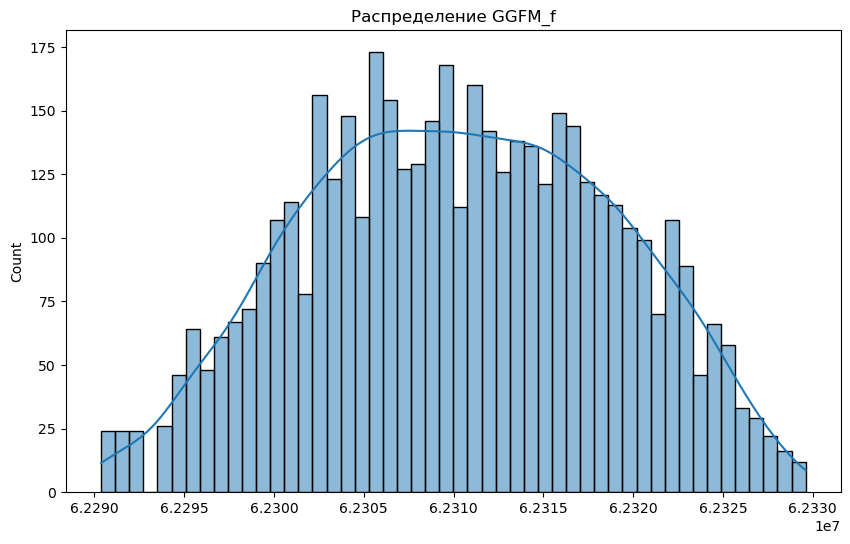

Выбросы в целевой переменной: 0


In [19]:
print("Размер датасета:", loader.colorado.shape)
print("Пропущенные значения:")
print(loader.colorado.isnull().sum())
print("nСтатистика целевой переменной:")
print(target.describe())

# Визуализация распределения целевой переменной
plt.figure(figsize=(10, 6))
sns.histplot(target.values.flatten(), bins=50, kde=True)
plt.title("Распределение GGFM_f")
plt.show()

# Проверка выбросов
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
outliers = ((target < (Q1 - 1.5 * IQR)) | (target > (Q3 + 1.5 * IQR))).sum()
print(f"Выбросы в целевой переменной: {outliers[0]}")

In [20]:
loader.colorado.head()

,Latitude (deg),Longitude (deg),Height (m),Height relief (m),Height geoid (m),r (m),GGFM_f,GGFM_g,TGFM_f,TGFM_g,Density (kg/m^3),Density STD (kg/m^3),x,y,z
index,,,,,,,,,,,,,,,
0,53.0,78.0,90.3125,129.0,-38.71875,6391887.5,62329260.0,9.742188,62317576.0,9.742188,2526.0,268.0,0.125122,0.588867,0.798828
1,53.0,78.0,290.2500,129.0,-38.71875,6392087.5,62327312.0,9.742188,62315628.0,9.742188,2526.0,268.0,0.125122,0.588867,0.798828
2,53.0,78.0,500.0000,129.0,-38.71875,6392297.5,62325268.0,9.742188,62313584.0,9.742188,2526.0,268.0,0.125122,0.588867,0.798828
3,53.0,78.0,590.5000,129.0,-38.71875,6392387.5,62324392.0,9.742188,62312704.0,9.742188,2526.0,268.0,0.125122,0.588867,0.798828
4,53.0,78.0,700.0000,129.0,-38.71875,6392497.5,62323324.0,9.742188,62311636.0,9.742188,2526.0,268.0,0.125122,0.588867,0.798828


# CatBoost

In [21]:
from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import joblib

In [23]:
import numpy as np
from scipy import ndimage

def laplacian_constraint_loss(y_true, y_pred, coordinates, alpha=0.1):
    """
    Кастомная функция потерь с учетом уравнения Лапласса
    
    Parameters:
    -----------
    y_true : array-like
        Истинные значения гравитационного потенциала
    y_pred : array-like
        Предсказанные значения гравитационного потенциала
    coordinates : array-like
        Координаты точек (широта, долгота, высота)
    alpha : float
        Вес лапласиана в общей функции потерь
    
    Returns:
    --------
    total_loss : float
        Общая функция потерь
    """
    from sklearn.neighbors import NearestNeighbors
    
    coords = np.array(coordinates)
    n_neighbors = 6  # Минимум 6 соседей для 3D лапласиана
    
    # Поиск ближайших соседей
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    laplacian = np.zeros(len(y_pred))
    
    for i in range(len(y_pred)):
        # Пропускаем саму точку (первый индекс)
        neighbor_indices = indices[i][1:]
        neighbor_dists = distances[i][1:]
        
        if len(neighbor_indices) >= 6:
            # Координаты соседей
            neighbor_coords = coords[neighbor_indices]
            neighbor_vals = y_pred[neighbor_indices]
            
            # Центрирование координат
            center_coord = coords[i]
            centered_coords = neighbor_coords - center_coord
            
            # Решение системы для вторых производных
            try:
                # Матрица гессиана
                A = centered_coords
                b = neighbor_vals - y_pred[i]
                
                # Решение методом наименьших квадратов
                derivatives, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
                
                # Лапласиан - след гессиана
                laplacian[i] = np.sum(derivatives[:3])  # Первые три производные
                
            except np.linalg.LinAlgError:
                laplacian[i] = 0
        else:
            laplacian[i] = 0
    
    return laplacian

def calculate_laplacian(potential, coordinates, h=0.01):
    """
    Вычисление лапласиана численным методом
    
    Parameters:
    -----------
    potential : array-like
        Значения гравитационного потенциала
    coordinates : array-like
        Координаты точек [lat, lon, height]
    h : float
        Шаг для численного дифференцирования
    
    Returns:
    --------
    laplacian : array-like
        Значения лапласиана для каждой точки
    """
    # Преобразуем в numpy массивы
    potential = np.array(potential).flatten()
    coords = np.array(coordinates)
    
    # Вычисляем вторые производные численно
    laplacian = np.zeros_like(potential)
    
    for i in range(len(potential)):
        # Точка, в которой вычисляем лапласиан
        center_coord = coords[i]
        center_pot = potential[i]
        
        # Находим ближайших соседей в каждом направлении
        neighbors = find_neighbors(i, coords, potential, h)
        
        if len(neighbors) >= 6:  # Нужно минимум 6 соседей для 3D лапласиана
            # Численное вычисление вторых производных
            d2x = second_derivative(neighbors, 'x', center_pot, h)
            d2y = second_derivative(neighbors, 'y', center_pot, h)
            d2z = second_derivative(neighbors, 'z', center_pot, h)
            
            laplacian[i] = d2x + d2y + d2z
        else:
            laplacian[i] = 0  # Недостаточно данных для вычисления
    
    return laplacian

def find_neighbors(center_idx, coordinates, values, radius=0.01):
    """
    Находит соседей в радиусе h от центральной точки
    """
    center = coordinates[center_idx]
    neighbors = []
    
    for i in range(len(coordinates)):
        if i == center_idx:
            continue
            
        dist = np.linalg.norm(coordinates[i] - center)
        if dist <= radius:
            neighbors.append({
                'idx': i,
                'coord': coordinates[i],
                'value': values[i],
                'dist': dist,
                'dx': coordinates[i][0] - center[0],
                'dy': coordinates[i][1] - center[1],
                'dz': coordinates[i][2] - center[2]
            })
    
    return neighbors

def second_derivative(neighbors, direction, center_value, h):
    """
    Вычисляет вторую производную численно
    """
    if direction == 'x':
        pos_neighbors = [n for n in neighbors if n['dx'] > 0]
        neg_neighbors = [n for n in neighbors if n['dx'] < 0]
    elif direction == 'y':
        pos_neighbors = [n for n in neighbors if n['dy'] > 0]
        neg_neighbors = [n for n in neighbors if n['dy'] < 0]
    elif direction == 'z':
        pos_neighbors = [n for n in neighbors if n['dz'] > 0]
        neg_neighbors = [n for n in neighbors if n['dz'] < 0]
    else:
        return 0
    
    if not pos_neighbors or not neg_neighbors:
        return 0
    
    # Ближайшие соседи в каждом направлении
    pos_neighbor = min(pos_neighbors, key=lambda x: abs(x['dx'] if direction=='x' else abs(x['dy'] if direction=='y' else abs(x['dz']))))
    neg_neighbor = min(neg_neighbors, key=lambda x: abs(x['dx'] if direction=='x' else abs(x['dy'] if direction=='y' else abs(x['dz']))))
    
    # Численная вторая производная
    f_plus = pos_neighbor['value']
    f_minus = neg_neighbor['value']
    f_center = center_value
    
    # Вторая производная по формуле (f(x+h) - 2f(x) + f(x-h)) / h²
    d2f = (f_plus - 2 * f_center + f_minus) / (h ** 2)
    
    return d2f

In [24]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=CFG.RANDOM_STATE, shuffle=True
)

In [25]:
# Создаем Pool для CatBoost
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

In [26]:
class ImprovedLaplaceLoss:
    def __init__(self, coordinates, alpha=0.01, beta=0.001):
        self.coordinates = coordinates
        self.alpha = alpha  # Вес лапласиана
        self.beta = beta    # Вес градиента
        
    def __call__(self, y_true, y_pred):
        # Основная MSE
        mse_loss = np.mean((y_true - y_pred) ** 2)
        
        # Условие Лапласса
        laplacian = laplacian_constraint_loss(y_pred, self.coordinates)
        laplace_loss = np.mean(laplacian ** 2)
        
        # Условие на градиент (опционально)
        grad_loss = self.calculate_gradient_constraint(y_pred, self.coordinates)
        
        total_loss = mse_loss + self.alpha * laplace_loss + self.beta * grad_loss
        
        return total_loss
    
    def calculate_gradient_constraint(self, y_pred, coordinates):
        """Регуляризация на гладкость градиента"""
        from sklearn.neighbors import NearestNeighbors
        
        nbrs = NearestNeighbors(n_neighbors=2).fit(coordinates)
        distances, indices = nbrs.kneighbors(coordinates)
        
        grad_variation = 0
        count = 0
        
        for i in range(len(y_pred)):
            if distances[i][1] > 0:  # Есть хотя бы один сосед
                j = indices[i][1]
                grad_ij = (y_pred[i] - y_pred[j]) / distances[i][1]
                grad_variation += grad_ij ** 2
                count += 1
        
        return grad_variation / count if count > 0 else 0

In [27]:
def create_advanced_model():
    """
    Создание ансамблевой модели
    """
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    from sklearn.svm import SVR
    from xgboost import XGBRegressor
    
    # Базовые модели
    base_models = [
        ('catboost', CatBoostRegressor(
            iterations=5000,
            learning_rate=0.001,
            depth=8,
            l2_leaf_reg=3,
            random_seed=CFG.RANDOM_STATE,
            verbose=False,
            task_type='CPU'
        )),
        ('xgb', XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=7,
            random_state=CFG.RANDOM_STATE
        )),
        ('svr', SVR(kernel='rbf', C=10, gamma='scale'))
    ]
    
    # Мета-модель
    meta_model = Ridge(alpha=1.0)
    
    # Стекинг
    stacking_model = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5,
        n_jobs=-1
    )
    
    return stacking_model

In [34]:
def advanced_training_pipeline():
    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=CFG.RANDOM_STATE, shuffle=True
    )
    
    # Масштабирование признаков
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Подготовка координат
    coord_cols = ['Latitude (deg)', 'Longitude (deg)', 'Height (m)']
    train_coords = X_train[coord_cols].values
    test_coords = X_test[coord_cols].values
    
    # Создание функции потерь
    loss_function = ImprovedLaplaceLoss(X_train[['x', 'y', 'z']], alpha=0.01, beta=0.001)
    
    # Обучение модели
    model = create_advanced_model()
    
    # Кастомная кросс-валидация
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_STATE)
    
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train_scaled):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        coords_fold = train_coords[train_idx]
        
        # Обучение с мониторингом
        model.fit(X_train_fold, y_train_fold.values.flatten())
        
        # Предсказание и оценка
        y_pred_val = model.predict(X_val_fold)
        score = loss_function(y_val_fold.values.flatten(), y_pred_val)
        cv_scores.append(score)
    
    print(f"CV Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
    
    # Финальное обучение
    model.fit(X_train_scaled, y_train.values.flatten())
    
    return model, scaler, loss_function

In [35]:
advanced_training_pipeline()

TypeError: laplacian_constraint_loss() missing 1 required positional argument: 'coordinates'

In [14]:
# Подготовка координат для условия Лапласса
coordinates = X_train[['Latitude (deg)','Longitude (deg)','Height (m)']].values

# Обучение с мониторингом кастомной функции потерь
class LaplaceConstraintCallback:
    def __init__(self, eval_pool, coordinates, alpha=0.1, check_every=100):
        self.eval_pool = eval_pool
        self.coordinates = coordinates  # [N, 3]
        self.alpha = alpha
        self.check_every = check_every
        self.best_score = float('inf')

    def after_iteration(self, info):
        if info.iteration % self.check_every == 0:
            try:
                # Получаем предсказания на валидации
                y_pred = info.model.predict(self.eval_pool.get_features())
                y_true = self.eval_pool.get_label()

                # Вычисляем лапласиан (на основе координат и предсказаний)
                laplacian = calculate_laplacian(y_pred, self.coordinates)
                laplace_loss = np.mean(laplacian ** 2)
                mse_loss = mean_squared_error(y_true, y_pred)

                total_loss = mse_loss + self.alpha * laplace_loss

                print(f"Iter {info.iteration}: MSE={mse_loss:.4f}, Laplace={laplace_loss:.4f}, Total={total_loss:.4f}")

                if total_loss < self.best_score:
                    self.best_score = total_loss
                    # info.model.save_model(f"best_model_iter_{info.iteration}.cbm")
            except Exception as e:
                print(f"Error in Laplace callback: {e}")
        return True

# Создаем callback
laplace_callback = LaplaceConstraintCallback(test_pool, coordinates, alpha=0.1)

In [33]:
def custom_objective(preds, train_data):
    """
    Кастомная функция для CatBoost с учетом условия Лапласса
    """
    y_true = train_data.get_label()
    coordinates = train_data.get_features()[:, :3]  # Предполагаем, что первые 3 колонки - координаты
    
    # Вычисление градиента и гессиана
    grad = np.gradient(preds.reshape(-1, 1), axis=0)
    hessian = np.gradient(grad, axis=0)
    
    # Лапласиан - след гессиана
    laplacian = np.trace(hessian, axis1=1, axis2=2)
    
    # Основная MSE loss
    mse_grad = 2 * (preds - y_true) / len(y_true)
    mse_hess = 2 * np.ones_like(preds) / len(y_true)
    
    # Лапласиан loss
    laplace_grad = 2 * laplacian / len(y_true)
    laplace_hess = 2 * np.ones_like(preds) / len(y_true)
    
    # Комбинированные градиент и гессиан
    total_grad = mse_grad + 0.1 * laplace_grad
    total_hess = mse_hess + 0.1 * laplace_hess
    
    return total_grad, total_hess

In [16]:
def objective(trial):
    """Двухэтапная оптимизация: сначала RMSE, потом добавляем лапласиан"""
    
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 10000),
        'learning_rate': trial.suggest_float('learning_rate', 0.000001, 0.0001, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'loss_function': 'RMSE',
        'verbose': False,
        'random_state': CFG.RANDOM_STATE,
        'task_type': 'GPU',
    }
    
    # Этап 1: Обычная кросс-валидация для RMSE
    cv_data = cv(
        params=params,
        pool=train_pool,
        fold_count=CFG.N_FOLDS,
        shuffle=True,
        partition_random_seed=CFG.RANDOM_STATE,
        plot=False,
        verbose=False
    )
    
    rmse_score = cv_data['test-RMSE-mean'].min()
    
    # Этап 2: Обучаем финальную модель и вычисляем лапласиан
    if rmse_score < trial.suggest_float('rmse_threshold', 0.1, 1.0):
        model = CatBoostRegressor(**params)
        model.fit(train_pool, verbose=False)
        
        y_pred = model.predict(train_pool.get_features())
        coordinates = train_pool.get_features()[:, :3]
        
        laplace_loss = np.mean(calculate_laplacian(y_pred, coordinates) ** 2)
        
        # Комбинированный score
        alpha = 0.1  # Фиксированный вес
        combined_score = rmse_score + alpha * laplace_loss
        
        trial.set_user_attr('laplace_loss', float(laplace_loss))
        return combined_score
    else:
        # Если RMSE слишком плохое, возвращаем большое значение
        return rmse_score * 2

In [ ]:
# Оптимизация гиперпараметров
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

# Лучшие параметры
best_params = study.best_params
print("Лучшие параметры:", best_params)

In [ ]:
# Обучение финальной модели с лучшими параметрами

# Сначала отфильтруем best_params, оставив только валидные для CatBoostRegressor
valid_catboost_params = {
    'iterations', 'learning_rate', 'depth', 'l2_leaf_reg',
    'bagging_temperature', 'random_strength', 'border_count',
    'grow_policy', 'loss_function', 'verbose', 'random_state',
    'task_type', 'early_stopping_rounds'
}

# Фильтруем параметры, оставляя только валидные
filtered_params = {k: v for k, v in best_params.items() if k in valid_catboost_params}

# Добавляем обязательные параметры
filtered_params.update({
    'loss_function': 'RMSE',
    'iterations': 100000,
    'verbose': 1000,
    'random_state': CFG.RANDOM_STATE,
    'task_type': 'CPU',
    'early_stopping_rounds': 500
})

print("Используемые параметры для CatBoost:")
for k, v in filtered_params.items():
    print(f"  {k}: {v}")

model = CatBoostRegressor(**filtered_params)

# Создаем callback для мониторинга условия Лапласса
class LaplaceMonitorCallback:
    def __init__(self, train_pool, eval_pool, coordinates, alpha=0.1, check_every=10):
        self.train_pool = train_pool
        self.eval_pool = eval_pool
        self.coordinates = coordinates
        self.alpha = alpha
        self.check_every = check_every
        self.best_combined_loss = float('inf')
        self.best_iteration = 0
        
    def after_iteration(self, info):
        if info.iteration % self.check_every == 0:
            try:
                # Предсказания на тренировочных данных для лапласиана
                y_pred_train = info.model.predict(self.train_pool.get_features())
                y_true_eval = self.eval_pool.get_label()
                y_pred_eval = info.model.predict(self.eval_pool.get_features())
                
                # Вычисление лапласиана
                laplacian = calculate_laplacian(y_pred_train, self.coordinates)
                laplace_loss = np.mean(laplacian ** 2)
                
                # MSE на валидации
                mse_loss = np.mean((y_true_eval - y_pred_eval) ** 2)
                
                # Комбинированная функция потерь
                combined_loss = mse_loss + self.alpha * laplace_loss
                
                print(f"Iteration {info.iteration}: MSE={mse_loss:.6f}, Laplace={laplace_loss:.6f}, Combined={combined_loss:.6f}")
                
                # Сохраняем лучшую модель
                if combined_loss < self.best_combined_loss:
                    self.best_combined_loss = combined_loss
                    self.best_iteration = info.iteration
                    # Можно сохранить модель здесь если нужно
                    
            except Exception as e:
                print(f"Error in Laplace monitoring: {e}")
        
        return True

# Подготовка координат
train_coordinates = X_train[['Latitude (deg)','Longitude (deg)','Height (m)']].values

# Создаем callback
laplace_callback = LaplaceMonitorCallback(
    train_pool=train_pool,
    eval_pool=test_pool,
    coordinates=train_coordinates,
    alpha=0.1,
    check_every=10
)

# Обучение модели
model.fit(
    train_pool,
    eval_set=test_pool,
    plot=True,
    use_best_model=True,
    callbacks=[laplace_callback]
)

print(f"Best combined loss: {laplace_callback.best_combined_loss:.6f} at iteration {laplace_callback.best_iteration}")

In [ ]:
# Предсказания
y_pred = model.predict(X_test)

# Оценка модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Feature importance
feature_importance = model.get_feature_importance()
feature_names = features.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(importance_df.head(10))

In [ ]:
# Визуализация важности признаков
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Визуализация предсказаний vs реальных значений
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

In [ ]:
# Остатки
residuals = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# Сохранение модели
model.save_model('catboost_gravity_model600.cbm')

# Сохранение с помощью joblib
joblib.dump(model, 'catboost_gravity_model600.joblib')

print("Модель успешно сохранена!")

In [51]:
# Загрузка модели (пример)
# loaded_model = CatBoostRegressor()
# loaded_model.load_model('catboost_gravity_model.cbm')

# Или с помощью joblib
# loaded_model = joblib.load('catboost_gravity_model.joblib')

In [ ]:
# Дополнительная оценка на всем датасете
full_pred = model.predict(features)
full_rmse = np.sqrt(mean_squared_error(target, full_pred))
print(f"RMSE на всем датасете: {full_rmse:.4f}")

In [ ]:
# SHAP значения для интерпретации модели
try:
    import shap
    
    # Инициализация SHAP объяснителя
    explainer = shap.TreeExplainer(model)
    
 # Вычисление SHAP значений для небольшой подвыборки
    shap_values = explainer.shap_values(X_test[:1000])
    
    # Визуализация summary plot
    shap.summary_plot(shap_values, X_test[:1000], feature_names=feature_names)
    
    # Визуализация force plot для одного наблюдения
    shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], 
                   feature_names=feature_names, matplotlib=True)
    
except ImportError:
    print("SHAP не установлен. Установите: pip install shap")